In [1]:
#Import the neccesary liberies
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

#Machine Learning Packages
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv('BostonHousing.csv')


In [9]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
data.shape

(506, 14)

In [6]:
data.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [7]:
data.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [10]:
data['rm'] = data['rm'].fillna(data['rm'].median())

In [11]:
data.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [12]:
#ML start from here

In [16]:
X = data.drop(columns = 'medv')
y = data['medv']

In [18]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

In [31]:
#Linear Regression

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
linear_reg.coef_

array([-8.16974632e-02,  4.80505044e-02, -3.60998656e-03,  3.05911093e+00,
       -1.60822701e+01,  3.65382131e+00, -8.02783948e-03, -1.50163013e+00,
        2.89379108e-01, -1.22365980e-02, -9.25071542e-01,  9.53826487e-03,
       -4.86902725e-01])

In [33]:
linear_reg.intercept_

np.float64(36.36775171646198)

In [36]:
y_pred = linear_reg.predict(X_test)

In [38]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

,Actual,Predicted
198,34.6,34.415632
229,31.5,31.162885
502,20.6,22.303464
31,14.5,17.907859
315,16.2,20.457951
...,...,...
166,50.0,36.167689
401,7.2,18.004978
368,50.0,23.213698
140,14.0,13.753083


In [47]:
RMSE = r2_score(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
print(f'The Root Mean Square is {RMSE}')
print(f'The Mean Squared Error is {MSE}')

The Root Mean Square is 0.7555230629779773
The Mean Squared Error is 23.615085948073364


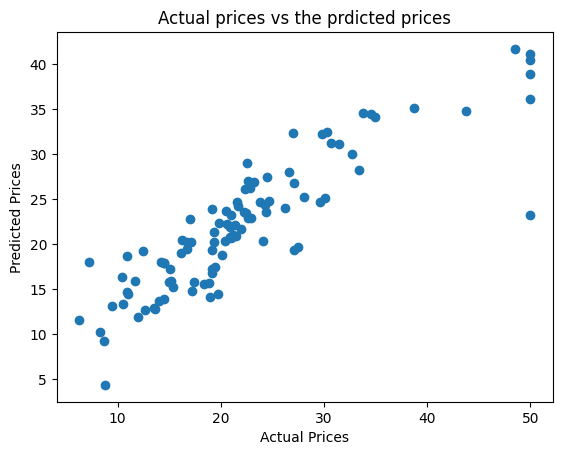

In [46]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual prices vs the prdicted prices')
plt.show()